## Agentic Rag with mulyiple tools

In [7]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [9]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [10]:
from langchain_ollama import OllamaEmbeddings
embeddings=OllamaEmbeddings(model="llama3.2:latest")

In [11]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding= embeddings
    # embedding=OpenAIEmbeddings()
)


retriever=vectorstore.as_retriever()

In [14]:
### Retriever To Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [15]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000270999A1940>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x0000027098740FE0>)

### Langchain Blogs- Seperate Vector Store


In [ ]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'Tutorials | 🦜️🔗 LangChain', 'description': 'New to LangChain or LLM app development in general? Read this material to quickly get up and running building your first applications.', 'language': 'en'}, page_content='\n\n\n\n\nTutorials | 🦜️🔗 LangChain\n\n\n\n\n\n\nSkip to main contentJoin us at  Interrupt: The Agent AI Conference by LangChain on May 13 & 14 in San Francisco!IntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1💬SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system over SQL d

In [18]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
    # embedding=OpenAIEmbeddings()
)


retrieverlangchain=vectorstorelangchain.as_retriever()

In [19]:
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [20]:
tools=[retriever_tool,retriever_tool_langchain]

In [22]:
retriever.invoke("what is langchain")

[Document(id='30a1c00b-99b1-4035-a141-db99f3c9bfb0', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='7657788d-d55a-4888-b3dc-cb05e486727f', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='62083891-8109-4c5b-9332-0fab470a72d3', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

### Langgraph Workflow

In [27]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [23]:
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]


In [24]:
from langchain_ollama import ChatOllama
llm=ChatOllama(model="llama3.2:latest")
llm

ChatOllama(model='llama3.2:latest')

In [25]:
def agent_node(state:AgentState)->AgentState:
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages=state["messages"]
    model=llm
    model_with_tools=llm.bind_tools(tools)
    response=model_with_tools.invoke(messages)
    return {"messages":[response]}

In [28]:
def grade_documents(state:AgentState)->Literal['generate','rewrite']:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")
    class Grade(BaseModel):
        binary_score:str=Field(description='Relevance Score "yes" or "no"')
    
    model=llm
    llm_with_tool=llm.with_structured_output(Grade)
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )
    chain=prompt | llm_with_tool
    last_message=state["messages"][-1]
    question=last_message.content
    docs=last_message.content

    scored_result=chain.invoke({"context":docs,"question":question})
    score=scored_result.binary_score
    if score=="yes":
        print("Documents are relevant, proceed to generate answer")
        return "generate"
    else:
        print("Documents are not relevant, rewrite the question to be more specific")
        return "rewrite"


In [29]:
def generate(state:AgentState):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = llm

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [31]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = llm
    response = model.invoke(msg)
    return {"messages": [response]}

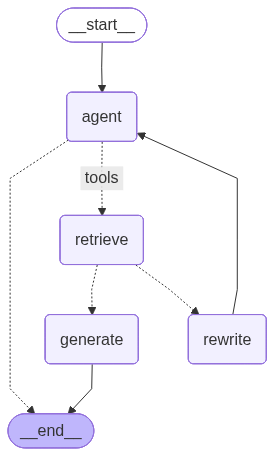

In [35]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import display,Markdown,Image
workflow=StateGraph(AgentState)

retrieve=ToolNode([retriever_tool_langchain,retriever_tool])

workflow.add_node("agent",agent_node)
workflow.add_node("rewrite",rewrite)
workflow.add_node("retrieve",retrieve)
workflow.add_node("generate",generate)


workflow.add_edge(START,"agent")
workflow.add_conditional_edges(
    "agent",tools_condition,{
        "tools": "retrieve",
        END: END
    }
)
workflow.add_conditional_edges(
    "retrieve",grade_documents
)
workflow.add_edge("generate",END)
workflow.add_edge("rewrite","agent")

graph=workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
graph.invoke({"messages":"What is Langgraph?"})


---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='18da5c89-3820-4427-b4cd-70c355c11e26'),
  AIMessage(content='{"name": "Search and run information about Langgraph", "parameters": {"query": {"type": "string", "description": "query to look up in retriever"}}}', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-30T13:37:38.4288843Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7171968300, 'load_duration': 6639284400, 'prompt_eval_count': 212, 'prompt_eval_duration': 56802000, 'eval_count': 38, 'eval_duration': 412706500, 'model_name': 'llama3.2:latest'}, id='lc_run--019dde9b-e20e-7a81-86b3-6ed513216ad5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 212, 'output_tokens': 38, 'total_tokens': 250})]}

In [37]:
graph.invoke({"messages":"What is Langchain?"})


---CALL AGENT---
---CHECK RELEVANCE---
Documents are not relevant, rewrite the question to be more specific
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='c0de5139-3d87-4677-b242-fd71962b8b28'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-30T13:37:40.6288019Z', 'done': True, 'done_reason': 'stop', 'total_duration': 673123900, 'load_duration': 165749900, 'prompt_eval_count': 212, 'prompt_eval_duration': 77195000, 'eval_count': 36, 'eval_duration': 392383200, 'model_name': 'llama3.2:latest'}, id='lc_run--019dde9c-0472-7cc1-92b5-e36c4b4e8162-0', tool_calls=[{'name': 'retriever_vector_langchain_blog', 'args': {'query': {'description': 'What is Langchain?', 'type': 'string'}}, 'id': '7e8fde7b-fadc-4ab6-aecd-13aa4d7152cc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 212, 'output_tokens': 36, 'total_tokens': 248}),
  ToolMessage(content="Error invoking tool 'retriever_vector_langchain_blog' with kwargs {'query': {'description': 'What is 

In [38]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---
---CHECK RELEVANCE---
Documents are not relevant, rewrite the question to be more specific
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='4448a998-9445-4f0f-829b-af33365ff518'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-30T13:37:46.4958064Z', 'done': True, 'done_reason': 'stop', 'total_duration': 547601000, 'load_duration': 120080000, 'prompt_eval_count': 212, 'prompt_eval_duration': 40219100, 'eval_count': 32, 'eval_duration': 354118500, 'model_name': 'llama3.2:latest'}, id='lc_run--019dde9c-1bda-7c02-8e59-ae21f2a4ffa9-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': {'description': 'Machine learning', 'type': 'string'}}, 'id': 'bd80645b-9f77-4dbb-bfc7-1806047afd6e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 212, 'output_tokens': 32, 'total_tokens': 244}),
  ToolMessage(content="Error invoking tool 'retriever_vector_db_blog' with kwargs {'query': {'description': 'Machine learning'